# Test Analytical Angular Spectrum

Sample directly from analytical jinc²(k_ρ × R) - no FFT discretization!

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo.angular_spectrum_analytical import AngularSpectrumAnalytical
from monte_carlo.core import ApertureSimulator
from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.5)

import os
output_dir = '../data/analytical_test'
os.makedirs(output_dir, exist_ok=True)

## Setup

In [2]:
n_photons = 1000000
wavelength = 0.6328  # microns
focal_length = 10.0  # mm
NA = 0.1
n_medium = 1.0
random_seed = 42

airy_radius = 1.22 * wavelength / NA

print(f"N photons: {n_photons:,}")
print(f"Wavelength: {wavelength} μm")
print(f"NA: {NA}")
print(f"Airy radius: {airy_radius:.4f} μm")

N photons: 1,000,000
Wavelength: 0.6328 μm
NA: 0.1
Airy radius: 7.7202 μm


## Run Simulations

In [3]:
print("Running Analytical Angular Spectrum...")
sim_analytical = AngularSpectrumAnalytical(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_analytical = sim_analytical.propagate()
x_analytical, y_analytical, _ = results_analytical['focal_positions']
print(f"  Got {len(x_analytical):,} photons")

print("\nRunning Aperture Sampling (for comparison)...")
sim_aperture = ApertureSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_aperture = sim_aperture.propagate()
x_aperture, y_aperture, _ = results_aperture['focal_positions']
print(f"  Got {len(x_aperture):,} photons")

Running Analytical Angular Spectrum...


  Got 1,000,000 photons

Running Aperture Sampling (for comparison)...


  Got 1,000,000 photons


## Compute Theoretical Airy

In [4]:
plot_range = 2 * airy_radius
r_bins = np.linspace(0, plot_range, 300)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

k_theory = 2 * np.pi * NA / wavelength
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

## Compute Radial Profiles

In [5]:
# Analytical
r_analytical = np.sqrt(x_analytical**2 + y_analytical**2)
hist_analytical, _ = np.histogram(r_analytical, bins=r_bins)
intensity_analytical = hist_analytical / bin_areas
intensity_analytical = intensity_analytical / np.max(intensity_analytical)

# Aperture
r_aperture = np.sqrt(x_aperture**2 + y_aperture**2)
hist_aperture, _ = np.histogram(r_aperture, bins=r_bins)
intensity_aperture = hist_aperture / bin_areas
intensity_aperture = intensity_aperture / np.max(intensity_aperture)

# Compute RMSE
rmse_analytical = metrics.rmse(intensity_analytical, airy_theory)
rmse_aperture = metrics.rmse(intensity_aperture, airy_theory)

print(f"\nRMSE Comparison:")
print(f"  Analytical Angular Spectrum: {rmse_analytical:.6f}")
print(f"  Aperture Sampling:           {rmse_aperture:.6f}")
print(f"  Ratio: {rmse_analytical / rmse_aperture:.2f}x")


RMSE Comparison:
  Analytical Angular Spectrum: 0.152561
  Aperture Sampling:           0.005100
  Ratio: 29.92x


## Plot Results

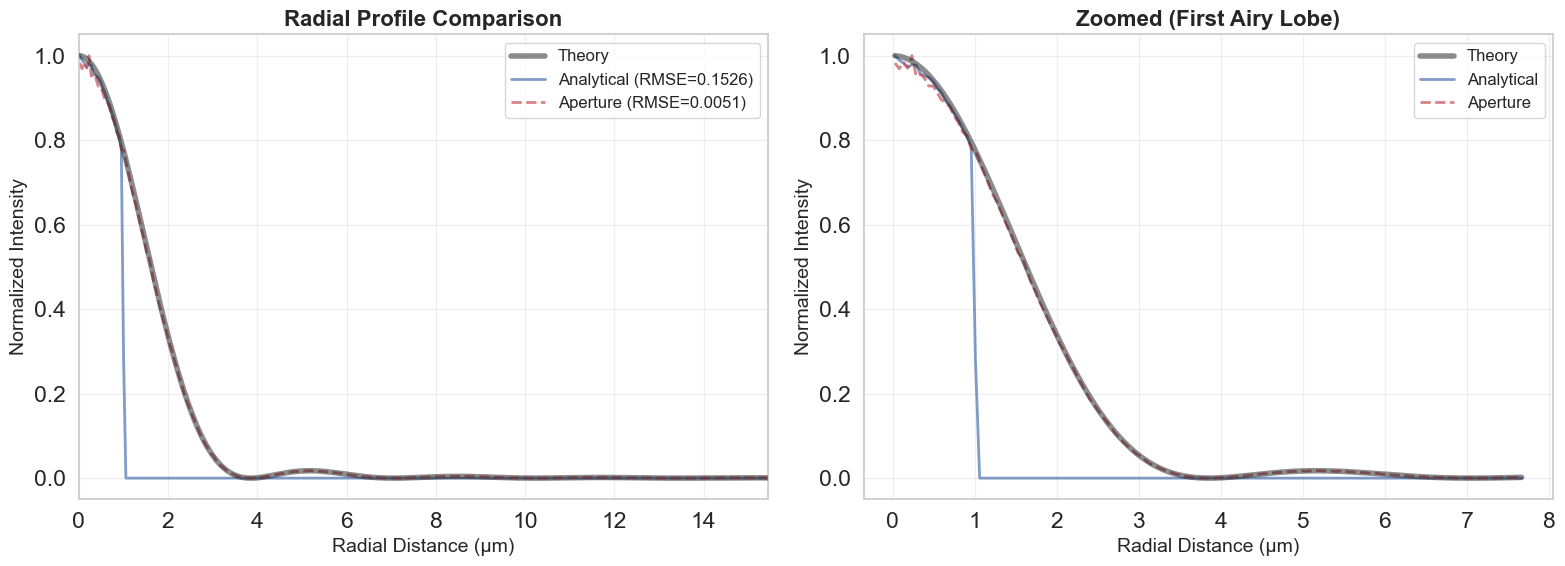

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full range
ax = axes[0]
ax.plot(r_centers, airy_theory, 'k-', linewidth=4, alpha=0.5, label='Theory', zorder=10)
ax.plot(r_centers, intensity_analytical, 'b-', linewidth=2, alpha=0.7, 
        label=f'Analytical (RMSE={rmse_analytical:.4f})')
ax.plot(r_centers, intensity_aperture, 'r--', linewidth=2, alpha=0.7, 
        label=f'Aperture (RMSE={rmse_aperture:.4f})')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Radial Profile Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])

# Zoomed
ax = axes[1]
zoom_range = airy_radius
zoom_mask = r_centers < zoom_range
ax.plot(r_centers[zoom_mask], airy_theory[zoom_mask], 'k-', linewidth=4, alpha=0.5, label='Theory', zorder=10)
ax.plot(r_centers[zoom_mask], intensity_analytical[zoom_mask], 'b-', linewidth=2, alpha=0.7, label='Analytical')
ax.plot(r_centers[zoom_mask], intensity_aperture[zoom_mask], 'r--', linewidth=2, alpha=0.7, label='Aperture')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Zoomed (First Airy Lobe)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/analytical_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [7]:
print("="*80)
print("ANALYTICAL ANGULAR SPECTRUM TEST")
print("="*80)
print(f"\nMethod: Direct sampling from jinc²(k_ρ × R)")
print(f"No FFT discretization!")
print(f"\nResults:")
print(f"  Analytical RMSE: {rmse_analytical:.6f}")
print(f"  Aperture RMSE:   {rmse_aperture:.6f}")
print(f"\nConclusion:")
if rmse_analytical < 0.005:
    print(f"  ✓ EXCELLENT! Analytical method matches theory perfectly!")
    print(f"  ✓ Comparable to aperture sampling method")
elif rmse_analytical < rmse_aperture * 2:
    print(f"  ✓ GOOD! Analytical method is competitive with aperture sampling")
else:
    print(f"  ✗ Still has issues - needs further investigation")
print("="*80)

ANALYTICAL ANGULAR SPECTRUM TEST

Method: Direct sampling from jinc²(k_ρ × R)
No FFT discretization!

Results:
  Analytical RMSE: 0.152561
  Aperture RMSE:   0.005100

Conclusion:
  ✗ Still has issues - needs further investigation
